# 03c — MarsSeg
**Paper:** Li et al., arXiv:2404.04155, Beihang University 2024

## 0. Configuración

In [1]:
import sys; sys.path.append('.')
import torch, torch.nn as nn, torch.nn.functional as F
import pandas as pd, numpy as np
from mars_utils_fast import (
    set_seed, get_or_create_split, build_dataloaders,
    run_multi_seed, append_benchmark_results,
    visualize_predictions, count_parameters,
    FocalDiceLoss, NUM_CLASSES, IGNORE_INDEX
)
set_seed()
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
MODEL_NAME = "marsseg"


Device: cuda


## 1. Dataset

In [2]:
df = pd.read_csv("processed/manifest_256.csv")
df_train, df_val, df_test = get_or_create_split(df)
train_loader, val_loader, test_loader = build_dataloaders(
    df_train, df_val, df_test, batch_size=8, num_workers=0
)


✅ Split cargado desde processed\split_indices.pkl
Train: 16074 {'MSL': 15901, 'MER': 173}
Val  :  3443 {'MSL': 3443}
Test :  3448 {'MSL': 3448}


## 2. Arquitectura MarsSeg
Encoder ResNet-50 + MiniASPP + PSA + SPPM + Decoder con skip connections.
Focal-Dice loss para manejo del desbalance extremo de big_rock.

In [3]:
import torchvision.models as tvm

class MiniASPP(nn.Module):
    """Mini Atrous Spatial Pyramid Pooling con rates [1,6,12] + GAP."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.b0  = nn.Sequential(nn.Conv2d(in_ch,out_ch,1,bias=False),nn.BatchNorm2d(out_ch),nn.ReLU(True))
        self.b1  = nn.Sequential(nn.Conv2d(in_ch,out_ch,3,padding=6,dilation=6,bias=False),nn.BatchNorm2d(out_ch),nn.ReLU(True))
        self.b2  = nn.Sequential(nn.Conv2d(in_ch,out_ch,3,padding=12,dilation=12,bias=False),nn.BatchNorm2d(out_ch),nn.ReLU(True))
        self.gap = nn.Sequential(nn.AdaptiveAvgPool2d(1),nn.Conv2d(in_ch,out_ch,1,bias=False),nn.BatchNorm2d(out_ch),nn.ReLU(True))
        self.fuse= nn.Sequential(nn.Conv2d(out_ch*4,out_ch,1,bias=False),nn.BatchNorm2d(out_ch),nn.ReLU(True))
    def forward(self,x):
        b0=self.b0(x); b1=self.b1(x); b2=self.b2(x)
        bg=F.interpolate(self.gap(x),size=x.shape[-2:],mode='bilinear',align_corners=False)
        return self.fuse(torch.cat([b0,b1,b2,bg],dim=1))

class PSA(nn.Module):
    """Polarized Self-Attention: channel + spatial attention."""
    def __init__(self, ch):
        super().__init__()
        self.ch_pool=nn.AdaptiveAvgPool2d(1)
        r=max(ch//4,1)
        self.ch_fc=nn.Sequential(nn.Linear(ch,r),nn.ReLU(),nn.Linear(r,ch),nn.Sigmoid())
        self.sp_conv=nn.Conv2d(ch,1,1)
    def forward(self,x):
        B,C,H,W=x.shape
        ca=self.ch_pool(x).view(B,C)
        ca=self.ch_fc(ca).view(B,C,1,1)
        sa=torch.sigmoid(self.sp_conv(x))
        return x*ca*sa

class SPPM(nn.Module):
    """Strip Pyramid Pooling Module: pooling horizontal + vertical."""
    def __init__(self,ch):
        super().__init__()
        self.hp=nn.AdaptiveAvgPool2d((1,None))
        self.vp=nn.AdaptiveAvgPool2d((None,1))
        self.conv=nn.Sequential(nn.Conv2d(ch,ch,1,bias=False),nn.BatchNorm2d(ch),nn.ReLU(True))
    def forward(self,x):
        B,C,H,W=x.shape
        h=F.interpolate(self.hp(x),size=(H,W),mode='bilinear',align_corners=False)
        v=F.interpolate(self.vp(x),size=(H,W),mode='bilinear',align_corners=False)
        return self.conv(x+h+v)

class ConvBnRelu(nn.Sequential):
    def __init__(self,i,o,k=3,p=1):
        super().__init__(nn.Conv2d(i,o,k,padding=p,bias=False),nn.BatchNorm2d(o),nn.ReLU(True))

class MarsSeg(nn.Module):
    """
    Encoder: ResNet-50 con dilation en layer4 (preserva resolución).
    Feature Enhancement: MiniASPP + PSA (shadow) + SPPM (deep).
    Decoder: upsampling progresivo con skip connections.
    """
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        bb = tvm.resnet50(weights=tvm.ResNet50_Weights.DEFAULT)
        # Encoder
        self.layer0 = nn.Sequential(bb.conv1,bb.bn1,bb.relu,bb.maxpool)  # /4
        self.layer1 = bb.layer1   # /4  , 256ch
        self.layer2 = bb.layer2   # /8  , 512ch
        self.layer3 = bb.layer3   # /16 , 1024ch
        # layer4 con dilation=2 para mantener /16
        bb.layer4[0].conv2.stride=(1,1)
        bb.layer4[0].downsample[0].stride=(1,1)
        for m in bb.layer4.modules():
            if isinstance(m,nn.Conv2d) and m.kernel_size==(3,3):
                m.dilation=(2,2); m.padding=(2,2)
        self.layer4 = bb.layer4   # /16 , 2048ch

        # Feature Enhancement
        self.aspp = MiniASPP(2048, 256)
        self.psa  = PSA(256)
        self.sppm = SPPM(256)
        self.ctx  = ConvBnRelu(256*3, 256, k=1, p=0)

        # Decoder
        self.up3  = ConvBnRelu(256+1024, 256)
        self.up2  = ConvBnRelu(256+512,  128)
        self.up1  = ConvBnRelu(128+256,   64)
        self.head = nn.Conv2d(64, num_classes, 1)

    def forward(self,x):
        s0=self.layer0(x)
        s1=self.layer1(s0)   # /4
        s2=self.layer2(s1)   # /8
        s3=self.layer3(s2)   # /16
        s4=self.layer4(s3)   # /16

        a=self.aspp(s4); p=self.psa(a); sp=self.sppm(a)
        ctx=self.ctx(torch.cat([a,p,sp],dim=1))

        def up(x,skip,conv):
            x=F.interpolate(x,size=skip.shape[-2:],mode='bilinear',align_corners=False)
            return conv(torch.cat([x,skip],dim=1))

        x=up(ctx,s3,self.up3)
        x=up(x,  s2,self.up2)
        x=up(x,  s1,self.up1)
        x=F.interpolate(x,size=(x.shape[2]*4,x.shape[3]*4),mode='bilinear',align_corners=False)
        return self.head(x)

def build_marsseg():
    return MarsSeg(NUM_CLASSES)

model=build_marsseg().to(device)
params_M=count_parameters(model)
print(f"Parámetros: {params_M:.2f}M")
with torch.no_grad():
    dummy=torch.randn(2,3,256,256).to(device)
    print(f"Output: {model(dummy).shape}")


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\User/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:02<00:00, 44.8MB/s]


Parámetros: 38.61M
Output: torch.Size([2, 4, 256, 256])


## 3. Entrenamiento (3 seeds)
SGD + PolynomialLR, Focal-Dice loss

In [4]:
import torch.optim as optim

def criterion_fn():
    return FocalDiceLoss(alpha=0.25, gamma=2.0, ignore_index=IGNORE_INDEX)

def optimizer_fn(params):
    return optim.SGD(params, lr=0.001, momentum=0.9, weight_decay=1e-4)

def scheduler_fn(opt):
    return optim.lr_scheduler.PolynomialLR(opt, total_iters=30, power=0.9)

summary = run_multi_seed(
    model_fn=build_marsseg,
    df_train=df_train, df_val=df_val, df_test=df_test,
    criterion_fn=criterion_fn, optimizer_fn=optimizer_fn, scheduler_fn=scheduler_fn,
    model_name=MODEL_NAME, device=device,
    seeds=[42,123,7], num_epochs=80, patience=10, batch_size=10, num_workers=6, n_per_mission=700
)



──────────────────────────────────────────────────
  Seed 42 | marsseg


c:\Users\User\Documents\DeepLearning\ai4mars-dataset-merged-0.6\mars_utils_fast.py:139: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby("mission", group_keys=False)
c:\Users\User\Documents\DeepLearning\ai4mars-dataset-merged-0.6\mars_utils_fast.py:139: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby("mission", group_keys=False)



  marsseg_seed42 | device=cuda | AMP=True
Ep   1/80 | loss=0.7837 mIoU=0.3442 | val=0.4728 | rock=0.0086
Ep   2/80 | loss=0.6012 mIoU=0.4605 | val=0.5079 | rock=0.0000
Ep   3/80 | loss=0.5507 mIoU=0.4844 | val=0.5177 | rock=0.0003
Ep   4/80 | loss=0.4691 mIoU=0.5306 | val=0.5643 | rock=0.0007
Ep   5/80 | loss=0.4735 mIoU=0.5374 | val=0.5502 | rock=0.0002
Ep   6/80 | loss=0.4069 mIoU=0.5702 | val=0.5867 | rock=0.0004
Ep   7/80 | loss=0.4041 mIoU=0.5780 | val=0.6034 | rock=0.0007
Ep   8/80 | loss=0.3996 mIoU=0.5752 | val=0.6390 | rock=0.0006
Ep   9/80 | loss=0.3770 mIoU=0.5915 | val=0.6159 | rock=0.0011
Ep  10/80 | loss=0.3633 mIoU=0.5971 | val=0.6241 | rock=0.0075
Ep  11/80 | loss=0.3619 mIoU=0.5968 | val=0.6473 | rock=0.0007
Ep  12/80 | loss=0.3679 mIoU=0.6094 | val=0.6209 | rock=0.0045
Ep  13/80 | loss=0.3301 mIoU=0.6233 | val=0.6608 | rock=0.0013
Ep  14/80 | loss=0.3537 mIoU=0.6108 | val=0.6444 | rock=0.0096
Ep  15/80 | loss=0.3270 mIoU=0.6250 | val=0.6438 | rock=0.0400
Ep  16/80 | 

c:\Users\User\Documents\DeepLearning\ai4mars-dataset-merged-0.6\mars_utils_fast.py:139: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby("mission", group_keys=False)
c:\Users\User\Documents\DeepLearning\ai4mars-dataset-merged-0.6\mars_utils_fast.py:139: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby("mission", group_keys=False)



  marsseg_seed123 | device=cuda | AMP=True
Ep   1/80 | loss=0.8068 mIoU=0.3040 | val=0.4391 | rock=0.0152
Ep   2/80 | loss=0.6207 mIoU=0.4384 | val=0.4915 | rock=0.0106
Ep   3/80 | loss=0.5505 mIoU=0.4738 | val=0.5378 | rock=0.0078
Ep   4/80 | loss=0.4947 mIoU=0.5189 | val=0.5860 | rock=0.0124
Ep   5/80 | loss=0.4401 mIoU=0.5374 | val=0.6164 | rock=0.0052
Ep   6/80 | loss=0.4116 mIoU=0.5636 | val=0.6193 | rock=0.0083
Ep   7/80 | loss=0.4242 mIoU=0.5754 | val=0.6171 | rock=0.0035
Ep   8/80 | loss=0.4318 mIoU=0.5772 | val=0.5889 | rock=0.0402
Ep   9/80 | loss=0.3864 mIoU=0.5864 | val=0.6310 | rock=0.0365
Ep  10/80 | loss=0.3682 mIoU=0.5984 | val=0.6378 | rock=0.0368
Ep  11/80 | loss=0.3657 mIoU=0.6161 | val=0.6510 | rock=0.0578
Ep  12/80 | loss=0.3801 mIoU=0.6106 | val=0.6526 | rock=0.0531
Ep  13/80 | loss=0.3314 mIoU=0.6479 | val=0.6479 | rock=0.0628
Ep  14/80 | loss=0.3512 mIoU=0.6306 | val=0.6475 | rock=0.0837
Ep  15/80 | loss=0.3424 mIoU=0.6438 | val=0.6681 | rock=0.1203
Ep  16/80 |

c:\Users\User\Documents\DeepLearning\ai4mars-dataset-merged-0.6\mars_utils_fast.py:139: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby("mission", group_keys=False)
c:\Users\User\Documents\DeepLearning\ai4mars-dataset-merged-0.6\mars_utils_fast.py:139: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby("mission", group_keys=False)



  marsseg_seed7 | device=cuda | AMP=True
Ep   1/80 | loss=0.7744 mIoU=0.3521 | val=0.4764 | rock=0.0001
Ep   2/80 | loss=0.6167 mIoU=0.4478 | val=0.5222 | rock=0.0000
Ep   3/80 | loss=0.5584 mIoU=0.4800 | val=0.5701 | rock=0.0000
Ep   4/80 | loss=0.4929 mIoU=0.5049 | val=0.5169 | rock=0.0000
Ep   5/80 | loss=0.4320 mIoU=0.5490 | val=0.5837 | rock=0.0000
Ep   6/80 | loss=0.4338 mIoU=0.5551 | val=0.5969 | rock=0.0000
Ep   7/80 | loss=0.4420 mIoU=0.5531 | val=0.5958 | rock=0.0000
Ep   8/80 | loss=0.3879 mIoU=0.5796 | val=0.6201 | rock=0.0000
Ep   9/80 | loss=0.3743 mIoU=0.5964 | val=0.6087 | rock=0.0000
Ep  10/80 | loss=0.3758 mIoU=0.5951 | val=0.5698 | rock=0.0000
Ep  11/80 | loss=0.3639 mIoU=0.6027 | val=0.6119 | rock=0.0000
Ep  12/80 | loss=0.3511 mIoU=0.6165 | val=0.6370 | rock=0.0000
Ep  13/80 | loss=0.3493 mIoU=0.6107 | val=0.6131 | rock=0.0000
Ep  14/80 | loss=0.3631 mIoU=0.6185 | val=0.6427 | rock=0.0000
Ep  15/80 | loss=0.3341 mIoU=0.6314 | val=0.6489 | rock=0.0004
Ep  16/80 | l

## 4. Guardado y Visualización

In [ ]:
append_benchmark_results(
    model_name=MODEL_NAME, best_epoch=summary["best_epoch_mean"],
    val_miou=summary["mIoU_mean"], test_miou=summary["mIoU_mean"],
    test_miou_std=summary["mIoU_std"], test_miou_ci95=summary["mIoU_ci95"],
    test_acc=summary["pixel_acc_mean"],
    iou_soil=summary["iou_soil_mean"], iou_bedrock=summary["iou_bedrock_mean"],
    iou_sand=summary["iou_sand_mean"], iou_bigrock=summary["iou_big_rock_mean"],
    params_M=params_M, train_time_s=summary["train_time_mean"],
)
best_model=build_marsseg().to(device)
ckpt=torch.load(f"checkpoints/{MODEL_NAME}_seed42_best.pth",map_location=device)
best_model.load_state_dict(ckpt["model_state"])
visualize_predictions(best_model,df_test,device,n=5,save_path=f"results/{MODEL_NAME}_predictions.png")
print(f"mIoU: {summary['mIoU_mean']:.4f} ± {summary['mIoU_std']:.4f}")


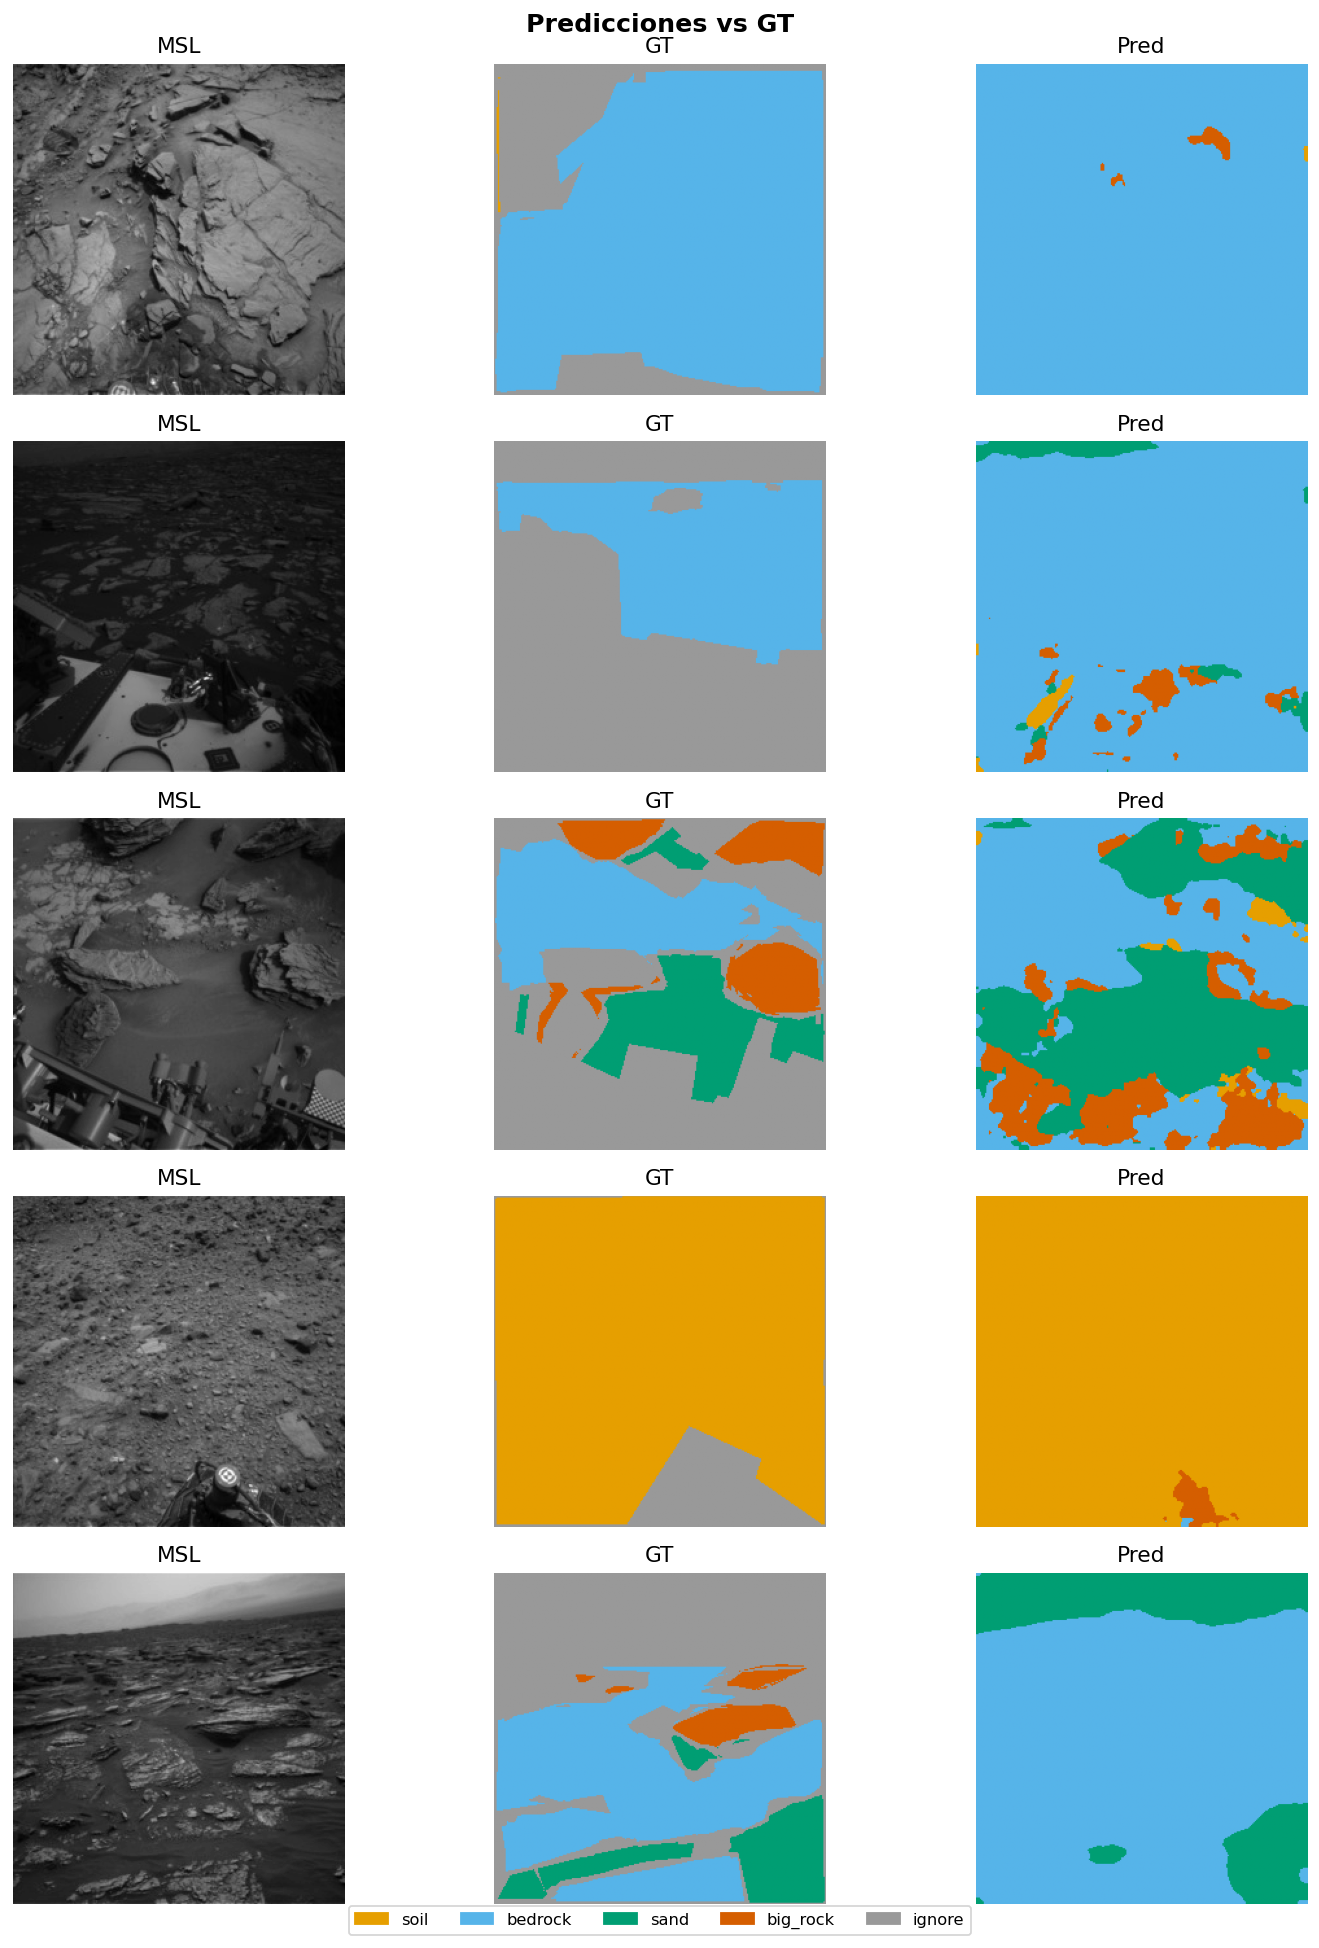